Churn distribution
Contract type vs churn
Monthly charges vs churn
Tenure distribution
Correlation heatmap
Feature importance insights

In [1]:
import pandas as pd
df = pd.read_csv(r'D:\Desktop\mlops\customer-churn-monitoring-mlops\data\raw\data.csv')

In [6]:
df.shape

(11000, 15)

In [2]:
df.columns

Index(['customer_id', 'tenure_months', 'monthly_charges', 'usage_minutes',
       'support_calls', 'payment_delay_days', 'contract_type', 'autopay',
       'num_services', 'satisfaction_score', 'signup_channel',
       'marketing_segment', 'favorite_color', 'lucky_number', 'churn'],
      dtype='str')

In [29]:
df['monthly_charges'].unique()

array([ 78.04, 140.22,  89.22, ...,  84.81,  88.4 , 143.62], shape=(7403,))

In [54]:
df.drop(columns = ['customer_id','favorite_color','lucky_number'], inplace = True)

In [55]:
df['satisfaction_score'].unique()

array([ 6.,  5., 10.,  4.,  9.,  7.,  2.,  8.,  1.,  3.])

In [56]:
df['satisfaction_score'] = df['satisfaction_score'].round()

In [57]:
df['satisfaction_score'].unique()

array([ 6.,  5., 10.,  4.,  9.,  7.,  2.,  8.,  1.,  3.])

In [58]:
df['churn'].unique()

array([0, 1])

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier

sns.set_style("whitegrid")

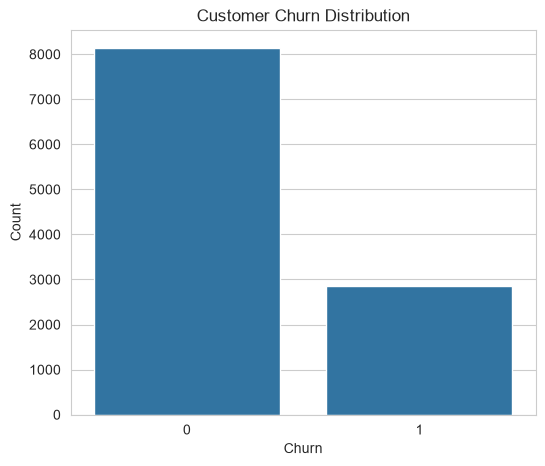

churn
0    8138
1    2862
Name: count, dtype: int64
churn
0    73.981818
1    26.018182
Name: proportion, dtype: float64


In [60]:
plt.figure(figsize=(6,5))

sns.countplot(x="churn", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

print(df["churn"].value_counts())
print(df["churn"].value_counts(normalize=True)*100)

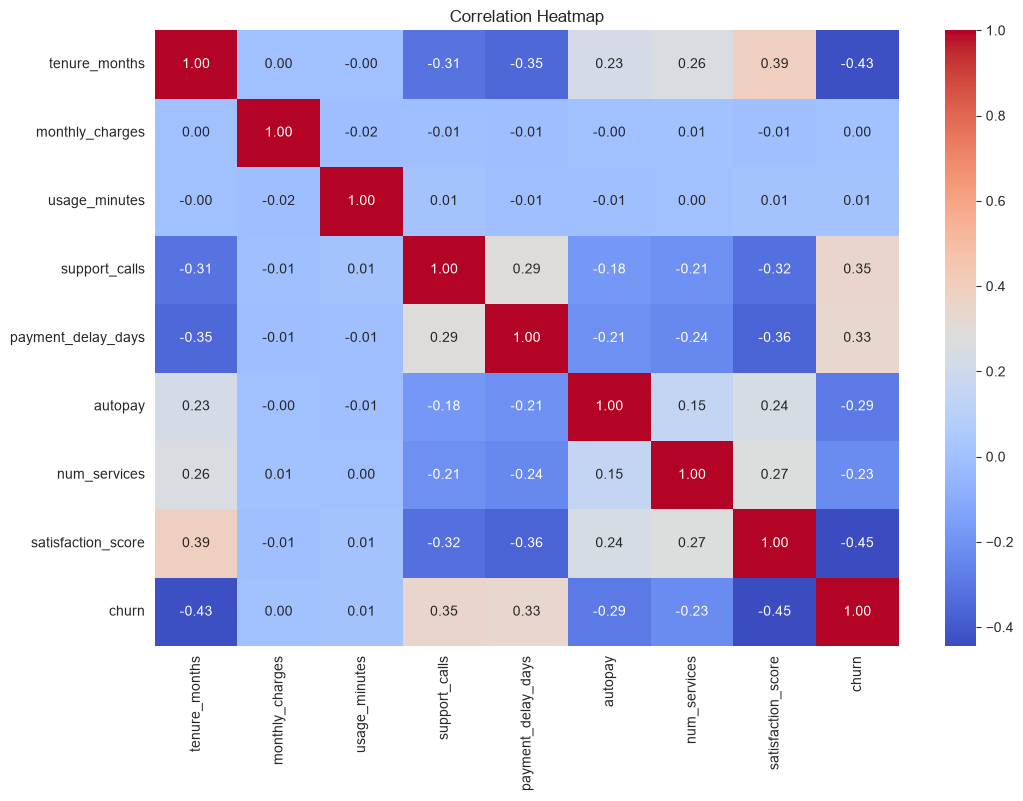

In [61]:
plt.figure(figsize=(12,8))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [62]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [63]:
X = df_encoded.drop("churn", axis=1)
y = df_encoded["churn"]

In [64]:
X.head(
)

,tenure_months,monthly_charges,usage_minutes,support_calls,payment_delay_days,autopay,num_services,satisfaction_score,contract_type_one-year,contract_type_two-year,signup_channel_organic,signup_channel_partner,signup_channel_referral,marketing_segment_B,marketing_segment_C
0,60,78.04,512,8,4.4,1,3,6.0,False,True,False,False,True,True,False
1,6,140.22,170,3,5.4,0,2,5.0,False,False,False,False,True,True,False
2,39,89.22,377,1,0.0,0,2,10.0,False,False,False,False,False,False,True
3,54,40.36,401,0,0.9,0,5,10.0,False,True,True,False,False,True,False
4,33,112.11,377,4,0.6,1,4,4.0,False,False,True,False,False,False,False


In [65]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [66]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(15))

                    Feature  Importance
0             tenure_months    0.197463
7        satisfaction_score    0.146645
4        payment_delay_days    0.129017
1           monthly_charges    0.110794
2             usage_minutes    0.107024
3             support_calls    0.097408
6              num_services    0.049128
5                   autopay    0.046296
9    contract_type_two-year    0.024065
8    contract_type_one-year    0.021826
13      marketing_segment_B    0.016315
14      marketing_segment_C    0.014371
12  signup_channel_referral    0.013887
10   signup_channel_organic    0.013711
11   signup_channel_partner    0.012051


In [68]:
importance

,Feature,Importance
0,tenure_months,0.197463
7,satisfaction_score,0.146645
4,payment_delay_days,0.129017
1,monthly_charges,0.110794
2,usage_minutes,0.107024
3,support_calls,0.097408
6,num_services,0.049128
5,autopay,0.046296
9,contract_type_two-year,0.024065
8,contract_type_one-year,0.021826


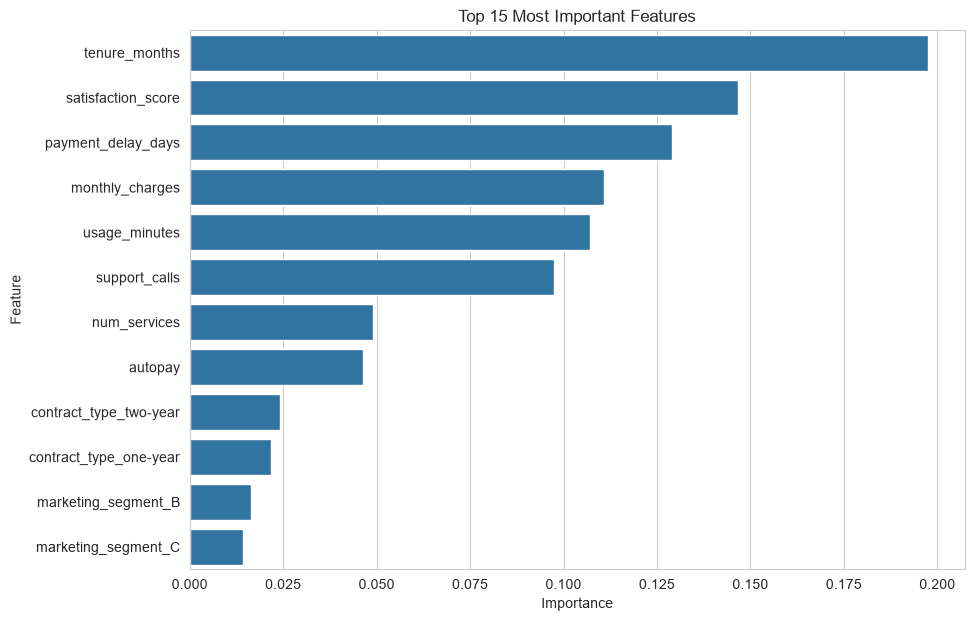

In [67]:
plt.figure(figsize=(10,7))

sns.barplot(
    data=importance.head(12),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Most Important Features")

plt.show()

## no need to drop any featrures

In [69]:
df.head()

,tenure_months,monthly_charges,usage_minutes,support_calls,payment_delay_days,contract_type,autopay,num_services,satisfaction_score,signup_channel,marketing_segment,churn
0,60,78.04,512,8,4.4,two-year,1,3,6.0,referral,B,0
1,6,140.22,170,3,5.4,month-to-month,0,2,5.0,referral,B,0
2,39,89.22,377,1,0.0,month-to-month,0,2,10.0,ads,C,1
3,54,40.36,401,0,0.9,two-year,0,5,10.0,organic,B,0
4,33,112.11,377,4,0.6,month-to-month,1,4,4.0,organic,A,0


In [75]:
df.to_csv(r'D:/Desktop/mlops/customer-churn-monitoring-mlops/data/processed/cleaned_data.csv', index=False)